In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [2]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

e:\anaconda3\envs\Graph_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\SRK for Gradient Flows\\utils.py'>

In [3]:
# Time and space range
a_x = 0
b_x = 2 * np.pi
a_y = 0
b_y = 2 * np.pi

#Initial x grid size and t grid size
Nx = 256
Ny = 256

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)

T = 8
eps = 0.1

bc= "Periodic"

save = True
save_path = "../../Results/Cahn_Hilliard_Comparison"
test_case = "sin(x)sin(y)"

print("eps used is " + str(eps))

eps used is 0.1


In [4]:
'''
Initial Condition for the Cahn-Hilliard simulation
'''
def initial_condition(mesh_grid):
    X, Y = mesh_grid
    return 0.05 * np.sin(X) * np.sin(Y) + 0.001

In [ ]:
method = "RKL2_2D_CH"
# method = "RKG2_2D_CH"

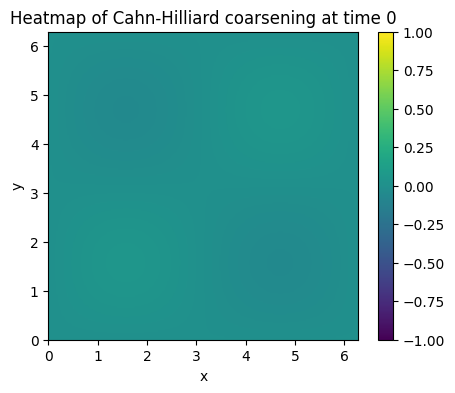

In [6]:
if method == "RKL2_2D_CH":
    s = 200
    dt = 1e-2
    plot_frequency = 100

    my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep(
        "RKL2_2D_CH", s, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, 
        initial_condition, T, eps, bc=bc, save=save, save_path=save_path, 
        plot_frequency=plot_frequency, test_case=test_case, energy_case=3
    )
elif method == "RKG2_2D_CH":
    s = 240
    dt = 1e-2
    plot_frequency = 100

    my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep(
        "RKG2_2D_CH", s, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, 
        initial_condition, T, eps, bc=bc, save=save, save_path=save_path, 
        plot_frequency=plot_frequency, test_case=test_case, energy_case=3
    )
else:
    raise ValueError("Invalid method")

my_solver.initialize(display=True)

Solving:   0%|                                                            | 0/801 [00:00<?, ?iter/s]

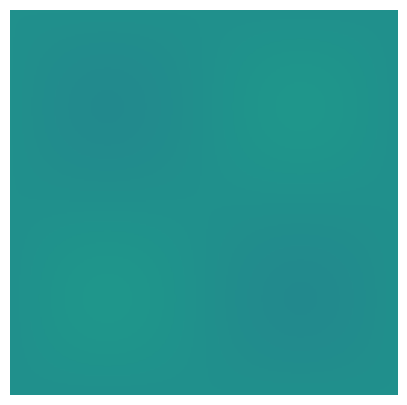

The max of u_total[-1] is 0.051000000000000004
The min of u_total[-1] is -0.049


Solving:  12%|██████▏                                           | 100/801 [02:24<13:25,  1.15s/iter]

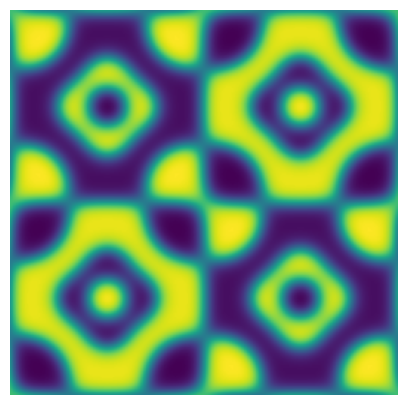

The max of u_total[-1] is 0.993208986813576
The min of u_total[-1] is -0.9984610276304323


Solving:  25%|████████████▍                                     | 200/801 [04:30<17:36,  1.76s/iter]

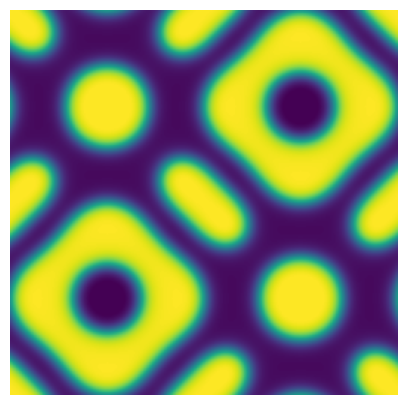

The max of u_total[-1] is 1.028377723866071
The min of u_total[-1] is -1.0433859483929393


Solving:  37%|██████████████████▋                               | 300/801 [07:17<13:28,  1.61s/iter]

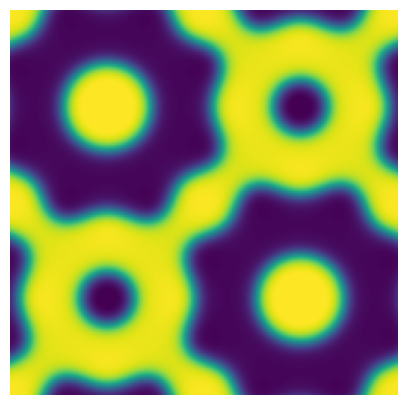

The max of u_total[-1] is 1.0302337498270602
The min of u_total[-1] is -1.0346258467529763


Solving:  50%|████████████████████████▉                         | 400/801 [10:01<12:32,  1.88s/iter]

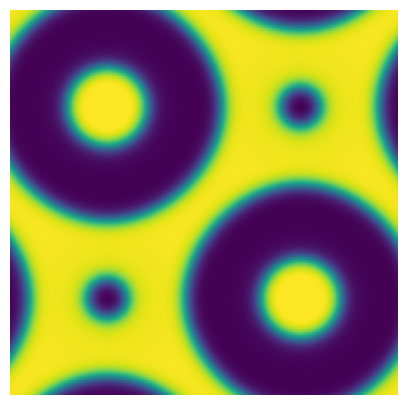

The max of u_total[-1] is 1.0386296854604475
The min of u_total[-1] is -0.9946950638477072


Solving:  62%|███████████████████████████████▏                  | 500/801 [12:27<08:32,  1.70s/iter]

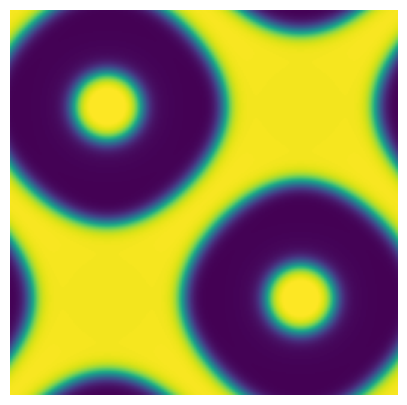

The max of u_total[-1] is 1.0418401721094592
The min of u_total[-1] is -0.9977966413831827


Solving:  75%|█████████████████████████████████████▍            | 600/801 [15:03<05:16,  1.57s/iter]

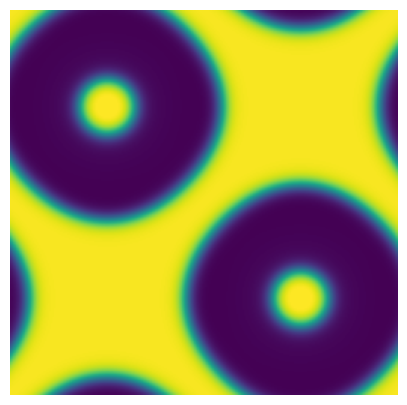

The max of u_total[-1] is 1.0406581038293048
The min of u_total[-1] is -0.9979153395128945


Solving:  87%|███████████████████████████████████████████▋      | 700/801 [17:46<03:00,  1.79s/iter]

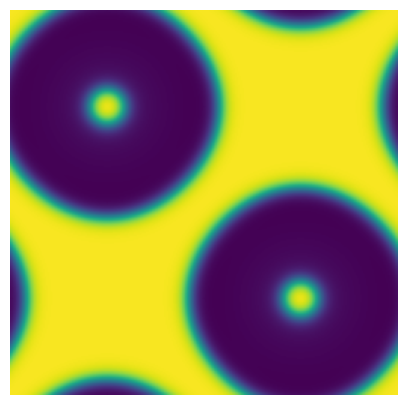

The max of u_total[-1] is 0.9828982586422104
The min of u_total[-1] is -0.9951381962369651


Solving: 100%|█████████████████████████████████████████████████▉| 800/801 [19:46<00:01,  1.18s/iter]

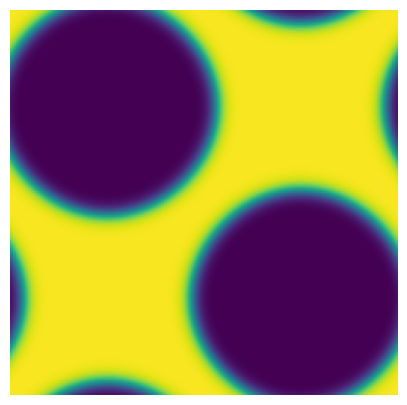

The max of u_total[-1] is 0.9842307049714873
The min of u_total[-1] is -1.0071710599237953


Solving: 100%|██████████████████████████████████████████████████| 801/801 [19:48<00:00,  1.48s/iter]


In [7]:
my_solver.solve()

In [8]:
u_total, t_total, energy_total, mesh_grid = my_solver.get_results()

In [9]:
print(my_solver.running_time)

1188.0674250125885


Figure saved to ../../Results/Cahn_Hilliard_Comparison/RKG2_2D_CH/RKG2_2D_CH_comparison_Nx256_Ny256_dt0.01_eps0.1000_T8_bcPeriodic_energy_case3.pdf


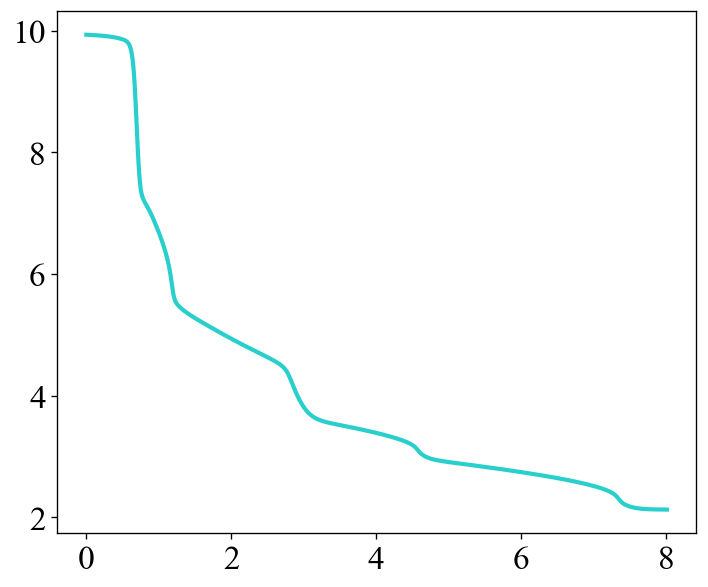

In [10]:
energy_gradient_total = energy_total[:, 0]
energy_non_linear_total = energy_total[:, 1]
energy = energy_gradient_total + energy_non_linear_total

# Journal of Computational Physics (Elsevier): Times New Roman for figures
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["mathtext.rm"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
# ax.plot(t_total, energy_gradient_total * dx**2, color="#2E86AB", lw=2, label="Gradient energy")
# ax.plot(t_total, energy_non_linear_total * dx**2, color="#A23B72", lw=2, label="Non-linear energy")
ax.plot(t_total[:], energy[:] * dx**2, color="#29cfcc", lw=2.5)

from matplotlib.ticker import FuncFormatter, MultipleLocator

config_title = f"{save_path}/{method}/{method}_comparison_Nx{Nx}_Ny{Ny}_dt{dt}_eps{eps:.4f}_T{T}_bc{bc}_energy_case3"


label_font = {"fontsize": 12, "fontfamily": "Times New Roman"}
# ax.set_xlabel("Time $t$", **label_font)
# ax.set_ylabel("Energy", **label_font)
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e2:.0f}"))
# ax.yaxis.set_major_locator(MultipleLocator(100))
# ax.text(-0.01, 1.02, r"$\times\,10^{2}$",
#         transform=ax.transAxes,
#         fontsize=20,
#         fontfamily="Times New Roman",
#         va="bottom")
ax.tick_params(axis="both", labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
# ax.legend(loc="best", frameon=True, prop={"family": "serif", "size": 14})
# ax.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
# ax.set_xticks([0, 0.02, 0.04, 0.06, 0.08])
# ax.set_yticks([200, 400, 600, 800, 1000])
fig.tight_layout()

if save:
    energy_save_path = f"{config_title}.pdf"
    fig.savefig(energy_save_path, bbox_inches="tight")
    print(f"Figure saved to {energy_save_path}")
plt.show()

8.009999999999874


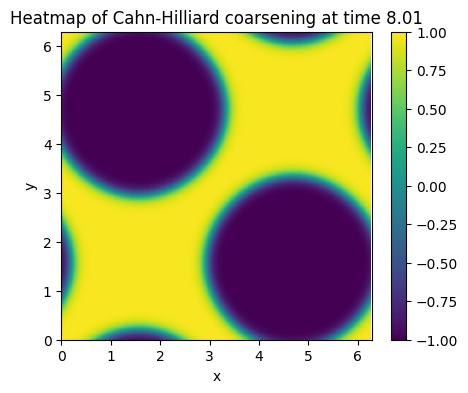

In [11]:
print(t_total[-1])
my_solver.display(u_total[-1], [a_x, b_x, a_y, b_y], t_total[-1])

In [15]:
def is_monotone_decreasing(arr):
    return np.all(np.diff(arr) < 0)
print(is_monotone_decreasing(energy))

True


Generate animation

In [12]:
# import matplotlib.animation as animation

In [13]:
# utils.generate_anime(u_total, t_total, [a_x, b_x, a_y, b_y], save=True)

In [14]:
# fig, ax = plt.subplots()
# cax = ax.imshow(u_total[0], cmap='viridis', origin='lower')
# fig.colorbar(cax)

# def update(frame):
#     cax.set_data(u_total[frame])
#     ax.set_title(f'Current time: {round(t_total[frame], 5)}')
#     return [cax]

# ani = animation.FuncAnimation(fig, update, frames=len(u_total), blit=True)

# # Save as GIF
# ani.save('Natural Timestepping Cahn-Hilliard Coarsening.gif', writer='pillow', fps=10)